In [2]:
#Import necessary libraries
import tensorflow as tf
from tensorflow.keras import layers,models
from tensorflow.keras.layers import Dense,Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#Split the dataset into training and testing
(x_train,y_train),(x_test,y_test) = cifar10.load_data()
#Preprocess the dataset
x_train,x_test=x_train/255.0,x_test/255.0
y_train,y_test=to_categorical(y_train),to_categorical(y_test) 

In [4]:
def create_model(hidden_units=None,activation=None):
    model=Sequential([
        Flatten(input_shape=(32,32,3)),
        Dense(hidden_units[0],activation=activation),
        Dense(hidden_units[1],activation=activation),
        Dense(hidden_units[2],activation=activation),
        Dense(10,activation='softmax')
    ])
    return model

In [5]:
hidden_units_lists=[(512,256,128),(256,128,64),(1024,512,256)]
activation_list=['relu','tanh','sigmoid']
result_set={}
counter=1

In [6]:
for hidden_units in hidden_units_lists:
    for activation in activation_list:
        model=create_model(hidden_units=hidden_units,activation=activation)
        model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
        history=model.fit(x_train,y_train,epochs=5,batch_size=64,validation_data=(x_test,y_test))
        _,test_acc=model.evaluate(x_test,y_test)
        model_info={'Hidden Units':hidden_units,'Activation':activation,'Test_accuracy':round(test_acc*100,4)}
        result_set[counter]=model_info
        counter=counter+1
        

C:\Users\Namitha Anna Koshy\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.3256 - loss: 1.8687 - val_accuracy: 0.3547 - val_loss: 1.7706
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.4025 - loss: 1.6683 - val_accuracy: 0.4255 - val_loss: 1.5982
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.4337 - loss: 1.5818 - val_accuracy: 0.4218 - val_loss: 1.6130
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.4543 - loss: 1.5300 - val_accuracy: 0.4621 - val_loss: 1.5207
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.4686 - loss: 1.4842 - val_accuracy: 0.4473 - val_loss: 1.5567
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4473 - loss: 1.5567
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.2436 - loss: 2.0138 - val_accuracy: 0.2899 - val_loss: 1.9112
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.2959 - loss: 1.9083 - val_accuracy: 0.3029 - val_loss: 1.9139
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━

In [11]:
for i in result_set:
    print(f'Model{i}:{result_set[i]}\n')
#Model with maximum accuracy
best_model = max(result_set.items(), key=lambda x: x[1]["Test_accuracy"])
print(f"MODEL WITH MAX ACCURACY \n Model{best_model[0]}: {best_model[1]}")

Model1:{'Hidden Units': (512, 256, 128), 'Activation': 'relu', 'Test_accuracy': 44.73}

Model2:{'Hidden Units': (512, 256, 128), 'Activation': 'tanh', 'Test_accuracy': 32.77}

Model3:{'Hidden Units': (512, 256, 128), 'Activation': 'sigmoid', 'Test_accuracy': 42.09}

Model4:{'Hidden Units': (256, 128, 64), 'Activation': 'relu', 'Test_accuracy': 43.92}

Model5:{'Hidden Units': (256, 128, 64), 'Activation': 'tanh', 'Test_accuracy': 38.5}

Model6:{'Hidden Units': (256, 128, 64), 'Activation': 'sigmoid', 'Test_accuracy': 39.6}

Model7:{'Hidden Units': (1024, 512, 256), 'Activation': 'relu', 'Test_accuracy': 45.85}

Model8:{'Hidden Units': (1024, 512, 256), 'Activation': 'tanh', 'Test_accuracy': 33.53}

Model9:{'Hidden Units': (1024, 512, 256), 'Activation': 'sigmoid', 'Test_accuracy': 38.73}

MODEL WITH MAX ACCURACY 
 Model7: {'Hidden Units': (1024, 512, 256), 'Activation': 'relu', 'Test_accuracy': 45.85}


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


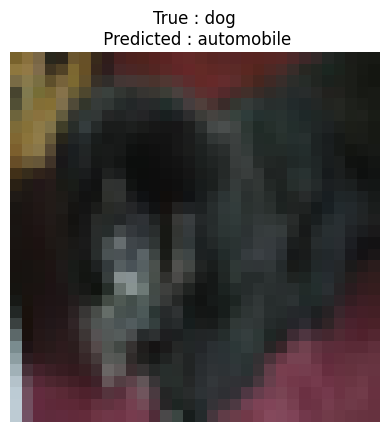

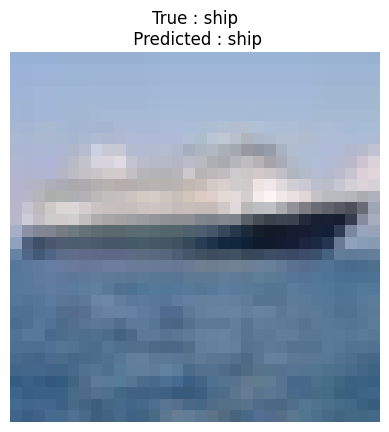

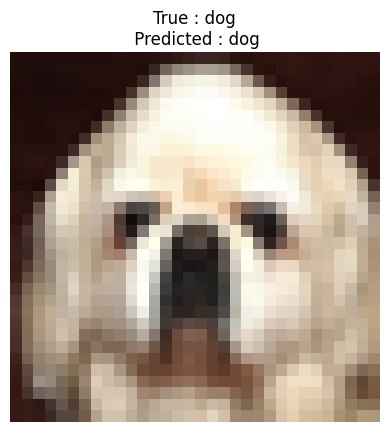

In [14]:
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
random_indices = np.random.choice(len(x_test),3,replace=False)
sample_images = x_test[random_indices]
sample_labels = y_test[random_indices]
predictions=model.predict(sample_images)
for i in range(3):
    predicted_label=class_names[np.argmax(predictions[i])]
    true_label = class_names[np.argmax(sample_labels[i])]
    plt.imshow(sample_images[i])
    plt.title(f"True : {true_label}\n Predicted : {predicted_label}")
    plt.axis('off')
    plt.show()
    